<h1 align="center">Group Relative Policy Optimization</h1>

---

<center><h2>Lesson 10</h2></center>

## **Intro to GRPO: Group-Based Policy Optimization for LLM Post-Training**

- Explain what **GRPO** is and why it is useful for language-model post-training.
- Compare **PPO** and **GRPO**, especially the role of the critic/value model.
- Compute **group-relative advantages** from a batch of sampled responses.
- Interpret the **clipped objective** and **KL regularization** used to keep updates stable.
- Build a small, runnable **toy GRPO-style optimization loop** on a categorical policy.
- Connect GRPO ideas to biomedical AI tasks such as answer ranking, report drafting, and reasoning alignment.

## What is GRPO?

**Group Relative Policy Optimization (GRPO)** is a policy optimization method used in modern LLM post-training. Instead of relying on a learned **value model** to estimate advantages, GRPO compares multiple responses generated for the **same prompt** and scores them **relative to each other**.

That makes the core loop simple:

1. Sample one prompt.
2. Generate a **group** of candidate responses from the current policy.
3. Score those responses with a reward function or verifier.
4. Normalize rewards within the group to form **relative advantages**.
5. Update the policy to increase the probability of better-than-average responses and decrease the probability of worse-than-average responses.

## PPO vs. GRPO

| Idea | PPO | GRPO |
|---|---|---|
| Advantage estimate | Uses a critic/value function | Uses relative rewards inside a sampled group |
| Extra model | Usually needs actor + critic | Often needs only the policy model plus reward scoring |
| Typical setting | General RL and RLHF | LLM post-training and reasoning alignment |
| Stability tools | Clipping + KL control | Clipping + KL control |
| Main tradeoff | Lower-variance estimate, but more machinery | Simpler setup, but advantage quality depends on group sampling |

A useful mental model is: **PPO asks, "Was this action better than the critic expected?"** GRPO asks, **"Was this response better than the other responses for the same prompt?"**

## The Core Math

Suppose a prompt $x$ produces a group of $G$ sampled responses $y_1, y_2, \ldots, y_G$. Let the reward model or verifier assign scores $r_1, r_2, \ldots, r_G$.

A simple group-relative advantage is:

$$A_i = \frac{r_i - \mu_r}{\sigma_r + \varepsilon}$$

where $\mu_r$ and $\sigma_r$ are the mean and standard deviation of the rewards within that group.

Like PPO, GRPO uses a clipped policy ratio:

$$\rho_i(\theta) = \frac{\pi_\theta(y_i \mid x)}{\pi_{\theta_{\text{old}}}(y_i \mid x)}$$

and optimizes a surrogate objective of the form:

$$\mathcal{L}_{\text{GRPO}} = \mathbb{E}\left[\min\left(\rho_i A_i,\; \text{clip}(\rho_i, 1-\epsilon, 1+\epsilon) A_i\right)\right] - \beta \, D_{KL}(\pi_\theta \,\|\, \pi_{\text{ref}})$$

The first term improves the policy using relative advantages. The KL term keeps the new policy from drifting too far from a reference model.

## Why This Matters for LLMs

In LLM post-training, a single prompt can have many plausible answers. Absolute reward scales can vary a lot across prompts, but **relative ranking within one prompt** is often much more meaningful.

Examples:

- One answer may be more factually correct.
- Another may have better reasoning steps.
- Another may be too verbose or unsafe.

GRPO turns these within-prompt comparisons into a training signal without needing a separate critic to predict values for every token sequence.

In [1]:
%pip install numpy matplotlib pandas -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=3, suppress=True)
rng = np.random.default_rng(42)

---

# Part 1: Group-Relative Advantages

The first thing GRPO needs is a way to convert raw rewards into a **relative learning signal**. We will start with a tiny synthetic example: several responses were sampled for the same prompt, and each received a scalar reward.

In [3]:
def group_relative_advantages(rewards, eps=1e-8):
    """Normalize rewards within a sampled group."""
    rewards = np.asarray(rewards, dtype=float)
    mean_reward = rewards.mean()
    std_reward = rewards.std()
    return (rewards - mean_reward) / (std_reward + eps)

sample_rewards = np.array([0.15, 0.85, 0.42, -0.10, 1.05, 0.51])
advantages = group_relative_advantages(sample_rewards)

table = pd.DataFrame({
    "response_id": np.arange(1, len(sample_rewards) + 1),
    "reward": sample_rewards,
    "relative_advantage": advantages,
})

print(f"Group mean reward: {sample_rewards.mean():.3f}")
print(f"Group std reward:  {sample_rewards.std():.3f}")
table

Group mean reward: 0.480
Group std reward:  0.390


,response_id,reward,relative_advantage
0,1,0.15,-0.846618
1,2,0.85,0.949238
2,3,0.42,-0.153931
3,4,-0.10,-1.487995
4,5,1.05,1.462340
5,6,0.51,0.076965


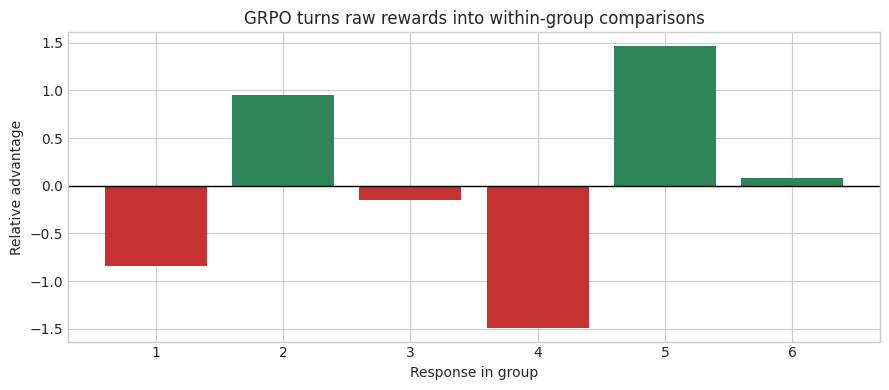

In [4]:
colors = ["#2f855a" if value >= 0 else "#c53030" for value in advantages]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(table["response_id"].astype(str), table["relative_advantage"], color=colors)
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("Response in group")
ax.set_ylabel("Relative advantage")
ax.set_title("GRPO turns raw rewards into within-group comparisons")
plt.tight_layout()
plt.show()

---

# Part 2: Toy LLM Example

Imagine one prompt asks for a short biomedical explanation. We sampled four candidate responses and assigned a synthetic reward to each one based on correctness, clarity, and safety.

In [5]:
prompt = "Explain why insulin is important in glucose regulation."
responses = [
    "Insulin helps cells take up glucose and lowers blood sugar after meals.",
    "Insulin is a hormone from the pancreas that promotes glucose uptake and storage.",
    "Insulin is kind of related to energy and metabolism in a general sense.",
    "Insulin raises blood glucose by blocking glucose entry into cells.",
]
rewards = np.array([0.82, 0.95, 0.20, -0.90])
advantages = group_relative_advantages(rewards)

response_table = pd.DataFrame({
    "prompt": [prompt] * len(responses),
    "response": responses,
    "reward": rewards,
    "relative_advantage": advantages,
}).sort_values("reward", ascending=False)

response_table

,prompt,response,reward,relative_advantage
1,Explain why insulin is important in glucose re...,Insulin is a hormone from the pancreas that pr...,0.95,0.933384
0,Explain why insulin is important in glucose re...,Insulin helps cells take up glucose and lowers...,0.82,0.755596
2,Explain why insulin is important in glucose re...,Insulin is kind of related to energy and metab...,0.20,-0.092313
3,Explain why insulin is important in glucose re...,Insulin raises blood glucose by blocking gluco...,-0.90,-1.596667


---

# Part 3: The Clipped Objective

Like PPO, GRPO uses clipping so the policy does not change too aggressively in one step. The next cells compute the unclipped and clipped objectives for a tiny synthetic batch and show how clipping limits extreme updates.

In [6]:
old_probs = np.array([0.25, 0.25, 0.25, 0.25])
new_probs = np.array([0.40, 0.18, 0.27, 0.15])
advantages = np.array([1.4, 0.5, -0.4, -1.1])
clip_eps = 0.2

ratio = new_probs / old_probs
clipped_ratio = np.clip(ratio, 1 - clip_eps, 1 + clip_eps)
unclipped_objective = ratio * advantages
clipped_objective = clipped_ratio * advantages
surrogate = np.minimum(unclipped_objective, clipped_objective)

clip_table = pd.DataFrame({
    "sample": [f"y{i}" for i in range(1, 5)],
    "advantage": advantages,
    "ratio": ratio,
    "clipped_ratio": clipped_ratio,
    "unclipped": unclipped_objective,
    "clipped": clipped_objective,
    "used_in_loss": surrogate,
})

clip_table

,sample,advantage,ratio,clipped_ratio,unclipped,clipped,used_in_loss
0,y1,1.4,1.60,1.20,2.240,1.680,1.680
1,y2,0.5,0.72,0.80,0.360,0.400,0.360
2,y3,-0.4,1.08,1.08,-0.432,-0.432,-0.432
3,y4,-1.1,0.60,0.80,-0.660,-0.880,-0.880


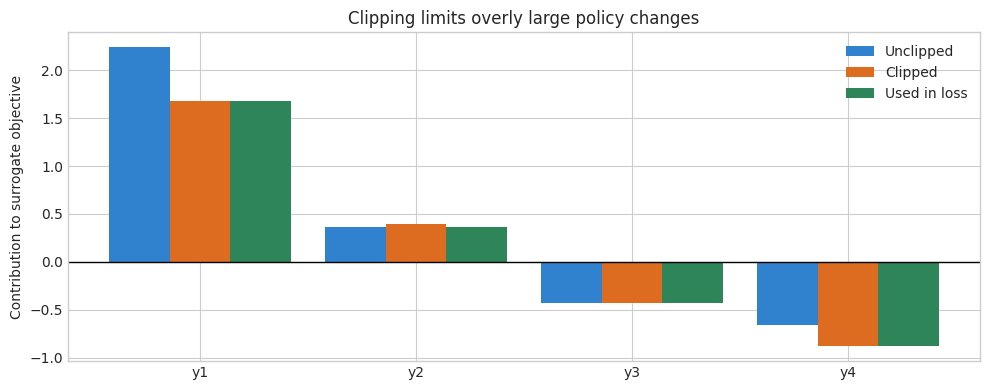

In [7]:
x = np.arange(len(advantages))
width = 0.28

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width, unclipped_objective, width=width, label="Unclipped", color="#3182ce")
ax.bar(x, clipped_objective, width=width, label="Clipped", color="#dd6b20")
ax.bar(x + width, surrogate, width=width, label="Used in loss", color="#2f855a")
ax.set_xticks(x)
ax.set_xticklabels([f"y{i}" for i in range(1, 5)])
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("Contribution to surrogate objective")
ax.set_title("Clipping limits overly large policy changes")
ax.legend()
plt.tight_layout()
plt.show()

### KL Regularization

Clipping controls the local update on sampled responses. The **KL penalty** controls global drift from a reference model. In practice, that helps preserve fluency, formatting, and general capabilities while still improving reward.

If $\beta$ is too small, the model may over-optimize the reward and become unstable. If $\beta$ is too large, the model may barely move at all.

---

# Part 4: A Tiny GRPO-Style Policy Update

The next example is **not** a production LLM trainer. It is a small categorical policy that mimics the main GRPO ingredients: sample a group of candidate outputs, score them, compute group-relative advantages, and update the policy while staying close to a reference distribution.

In [8]:
def softmax(logits):
    shifted = logits - np.max(logits)
    exp_values = np.exp(shifted)
    return exp_values / exp_values.sum()

def kl_divergence(p, q, eps=1e-8):
    return np.sum(p * (np.log(p + eps) - np.log(q + eps)))

labels = [
    "High-quality answer",
    "Mostly correct answer",
    "Vague answer",
    "Wrong answer",
]
reward_lookup = np.array([1.2, 0.7, 0.1, -0.8])
reference_logits = np.zeros(len(labels))
policy_logits = np.zeros(len(labels))

learning_rate = 0.30
beta = 0.08
group_size = 8
n_steps = 80

probability_history = []
kl_history = []

for step in range(n_steps):
    policy_probs = softmax(policy_logits)
    reference_probs = softmax(reference_logits)

    sampled_ids = rng.choice(len(labels), size=group_size, p=policy_probs)
    sampled_rewards = reward_lookup[sampled_ids] + rng.normal(0, 0.08, size=group_size)
    sampled_advantages = group_relative_advantages(sampled_rewards)

    gradient = np.zeros_like(policy_logits)
    for idx, advantage in zip(sampled_ids, sampled_advantages):
        one_hot = np.zeros_like(policy_logits)
        one_hot[idx] = 1.0
        gradient += advantage * (one_hot - policy_probs)

    gradient /= group_size
    kl_gradient = policy_probs - reference_probs
    policy_logits += learning_rate * (gradient - beta * kl_gradient)

    probability_history.append(policy_probs.copy())
    kl_history.append(kl_divergence(policy_probs, reference_probs))

probability_history = np.vstack(probability_history)
final_probs = softmax(policy_logits)

pd.DataFrame({
    "candidate": labels,
    "reward_signal": reward_lookup,
    "final_probability": final_probs,
}).sort_values("final_probability", ascending=False)

,candidate,reward_signal,final_probability
0,High-quality answer,1.2,0.976940
1,Mostly correct answer,0.7,0.012153
3,Wrong answer,-0.8,0.005975
2,Vague answer,0.1,0.004932


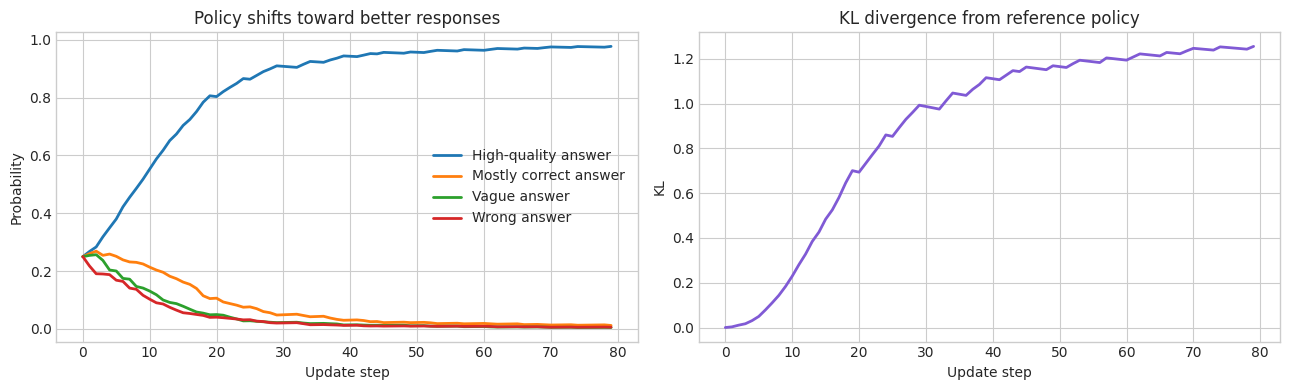

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for idx, label in enumerate(labels):
    axes[0].plot(probability_history[:, idx], linewidth=2, label=label)

axes[0].set_title("Policy shifts toward better responses")
axes[0].set_xlabel("Update step")
axes[0].set_ylabel("Probability")
axes[0].legend()

axes[1].plot(kl_history, color="#805ad5", linewidth=2)
axes[1].set_title("KL divergence from reference policy")
axes[1].set_xlabel("Update step")
axes[1].set_ylabel("KL")

plt.tight_layout()
plt.show()

### What this toy loop leaves out

Real GRPO for LLMs operates on token sequences, uses log-probabilities from a transformer, and usually combines reward modeling, batching, and memory-efficient training tricks. This demo only keeps the core conceptual pieces.

---

# Part 5: What a Real GRPO Workflow Looks Like

A practical GRPO workflow for an LLM often looks like this:

1. Start with a pretrained or supervised fine-tuned language model.
2. Sample several completions for each prompt.
3. Score completions using a reward model, a verifier, rule-based checks, or test cases.
4. Compute group-relative advantages within each prompt group.
5. Update the model with a clipped objective and KL regularization toward a reference model.
6. Re-evaluate on held-out prompts for accuracy, safety, and reward hacking.

Popular practical concerns include reward misspecification, mode collapse, instability when KL is weak, and evaluation gaps between reward score and real quality.

## Where GRPO Could Matter in Biomedical AI

Possible applications include:

- ranking multiple clinical note drafts for correctness and clarity,
- preferring mechanistic explanations that cite the right physiology,
- training a model to produce safer patient-facing summaries,
- improving step-by-step reasoning in biomedical question answering.

In these settings, the reward might combine factual accuracy, safety checks, citation quality, brevity, or rubric scores from human reviewers.

---



# Part 6: Hands-On Challenges

### ✏️ Challenge 1: Change the group size

Modify `group_size` in the toy optimization loop. How does a larger or smaller group change the smoothness of the learning signal?

### ✏️ Challenge 2: Tune the KL coefficient

Try `beta = 0.01`, `0.05`, and `0.20`. How much does the policy drift from the reference model in each case?

### ✏️ Challenge 3: Design a biomedical reward

Define a reward rubric for a biomedical explanation task. For example, combine factual correctness, completeness, safety, and readability. Then simulate a few candidate responses and compute their group-relative advantages.

---


Challenge 1: Effect of changing group_size


,group_size,avg_step_change,std_step_change,final_KL,final_prob_high_quality
0,4,0.014,0.017,1.097,0.940
1,8,0.012,0.015,1.215,0.968
2,16,0.013,0.015,1.259,0.978
3,32,0.012,0.014,1.260,0.978


Smaller groups produce a noisier learning signal because each update depends on fewer sampled responses. Larger groups average over more candidates, so the step-to-step policy changes become smoother.


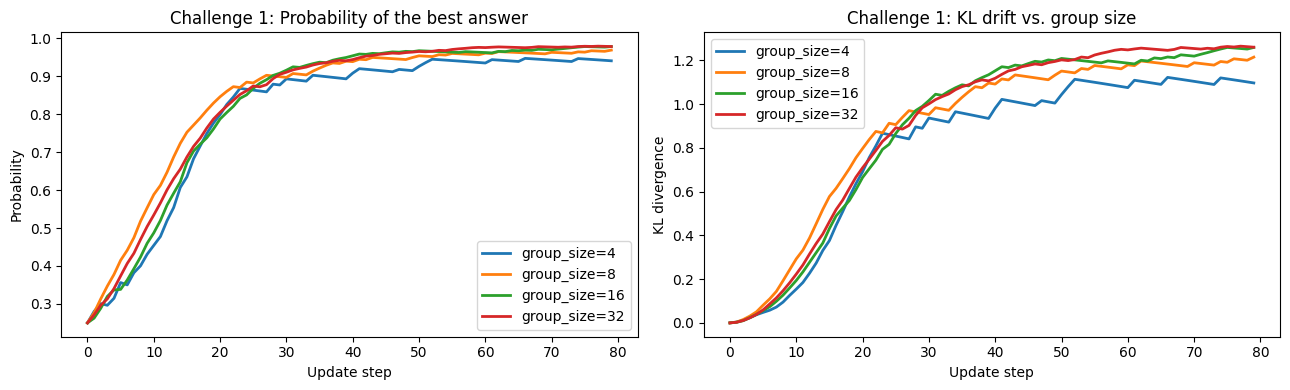


Challenge 2: Effect of tuning beta


,beta,final_KL,max_KL,final_prob_high_quality,final_prob_wrong_answer
0,0.01,1.275,1.275,0.982,0.005
1,0.05,1.235,1.235,0.973,0.007
2,0.20,1.111,1.111,0.941,0.017


A smaller beta lets the policy move farther from the reference model, so KL drift is larger. A larger beta keeps the policy closer to the reference model but also slows down how aggressively it favors the best answer.


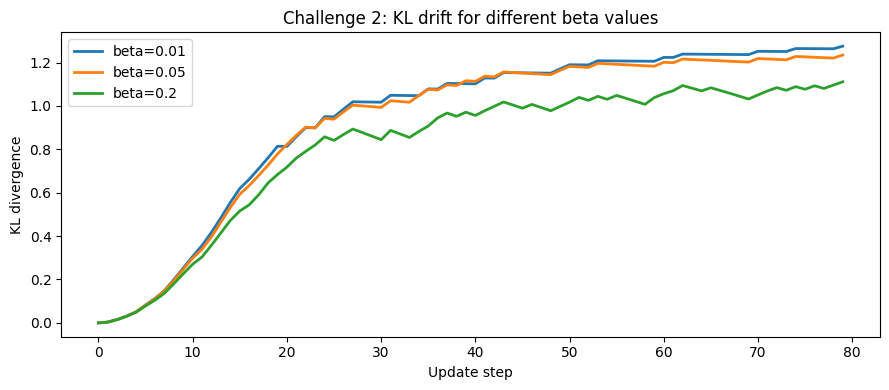


Challenge 3: Biomedical reward rubric for: Explain why antibiotics do not treat influenza.
Rubric weights: {'factual_correctness': 0.45, 'completeness': 0.25, 'safety': 0.2, 'readability': 0.1}


,candidate,response,factual_correctness,completeness,safety,readability,reward,relative_advantage
0,A,"Influenza is caused by a virus, so antibiotics...",5,5,5,4,4.9,1.239
1,B,"Antibiotics are used for bacterial infections,...",4,4,4,5,4.1,0.718
3,D,The flu is a virus and antibiotics are for bac...,2,2,0,3,1.7,-0.848
2,C,"Antibiotics boost the immune system, so they c...",1,1,1,4,1.3,-1.109


Candidate A ranks highest because it is correct, complete, and safe. Candidates C and D receive negative relative advantages because they contain factual or safety problems that the rubric penalizes.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def group_relative_advantages(rewards, eps=1e-8):
    rewards = np.asarray(rewards, dtype=float)
    return (rewards - rewards.mean()) / (rewards.std() + eps)



def softmax(logits):
    shifted = logits - np.max(logits)
    exp_values = np.exp(shifted)
    return exp_values / exp_values.sum()



def kl_divergence(p, q, eps=1e-8):
    return np.sum(p * (np.log(p + eps) - np.log(q + eps)))



def run_toy_grpo(group_size=8, beta=0.08, n_steps=80, seed=7):
    labels = [
        "High-quality answer",
        "Mostly correct answer",
        "Vague answer",
        "Wrong answer",
    ]
    reward_lookup = np.array([1.2, 0.7, 0.1, -0.8])
    reference_logits = np.zeros(len(labels))
    policy_logits = np.zeros(len(labels))
    learning_rate = 0.30
    local_rng = np.random.default_rng(seed)

    probability_history = []
    kl_history = []

    for _ in range(n_steps):
        policy_probs = softmax(policy_logits)
        reference_probs = softmax(reference_logits)

        sampled_ids = local_rng.choice(len(labels), size=group_size, p=policy_probs)
        sampled_rewards = reward_lookup[sampled_ids] + local_rng.normal(0, 0.08, size=group_size)
        sampled_advantages = group_relative_advantages(sampled_rewards)

        gradient = np.zeros_like(policy_logits)
        for idx, advantage in zip(sampled_ids, sampled_advantages):
            one_hot = np.zeros_like(policy_logits)
            one_hot[idx] = 1.0
            gradient += advantage * (one_hot - policy_probs)

        gradient /= group_size
        policy_logits += learning_rate * (gradient - beta * (policy_probs - reference_probs))

        probability_history.append(policy_probs.copy())
        kl_history.append(kl_divergence(policy_probs, reference_probs))

    probability_history = np.vstack(probability_history)
    step_changes = np.linalg.norm(np.diff(probability_history, axis=0), axis=1)

    return {
        "labels": labels,
        "final_probs": softmax(policy_logits),
        "probability_history": probability_history,
        "kl_history": np.array(kl_history),
        "avg_step_change": float(step_changes.mean()),
        "std_step_change": float(step_changes.std()),
    }


# Challenge 1: larger groups should average over more samples and look smoother.
group_sizes = [4, 8, 16, 32]
group_runs = {group_size: run_toy_grpo(group_size=group_size, beta=0.08) for group_size in group_sizes}

group_size_table = pd.DataFrame(
    [
        {
            "group_size": group_size,
            "avg_step_change": run["avg_step_change"],
            "std_step_change": run["std_step_change"],
            "final_KL": run["kl_history"][-1],
            "final_prob_high_quality": run["final_probs"][0],
        }
        for group_size, run in group_runs.items()
    ]
).round(3)

print("Challenge 1: Effect of changing group_size")
display(group_size_table)
print(
    "Smaller groups produce a noisier learning signal because each update depends on fewer sampled responses. "
    "Larger groups average over more candidates, so the step-to-step policy changes become smoother."
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for group_size, run in group_runs.items():
    axes[0].plot(
        run["probability_history"][:, 0],
        linewidth=2,
        label=f"group_size={group_size}",
    )
    axes[1].plot(
        run["kl_history"],
        linewidth=2,
        label=f"group_size={group_size}",
    )

axes[0].set_title("Challenge 1: Probability of the best answer")
axes[0].set_xlabel("Update step")
axes[0].set_ylabel("Probability")
axes[0].legend()
axes[1].set_title("Challenge 1: KL drift vs. group size")
axes[1].set_xlabel("Update step")
axes[1].set_ylabel("KL divergence")
axes[1].legend()
plt.tight_layout()
plt.show()


# Challenge 2: weaker KL penalties allow more drift from the reference model.
betas = [0.01, 0.05, 0.20]
beta_runs = {beta: run_toy_grpo(group_size=8, beta=beta) for beta in betas}

beta_table = pd.DataFrame(
    [
        {
            "beta": beta,
            "final_KL": run["kl_history"][-1],
            "max_KL": run["kl_history"].max(),
            "final_prob_high_quality": run["final_probs"][0],
            "final_prob_wrong_answer": run["final_probs"][-1],
        }
        for beta, run in beta_runs.items()
    ]
).round(3)

print("\nChallenge 2: Effect of tuning beta")
display(beta_table)
print(
    "A smaller beta lets the policy move farther from the reference model, so KL drift is larger. "
    "A larger beta keeps the policy closer to the reference model but also slows down how aggressively it favors the best answer."
)

fig, ax = plt.subplots(figsize=(9, 4))
for beta, run in beta_runs.items():
    ax.plot(run["kl_history"], linewidth=2, label=f"beta={beta}")

ax.set_title("Challenge 2: KL drift for different beta values")
ax.set_xlabel("Update step")
ax.set_ylabel("KL divergence")
ax.legend()
plt.tight_layout()
plt.show()


# Challenge 3: build a synthetic biomedical reward rubric and rank candidate explanations.
rubric_weights = {
    "factual_correctness": 0.45,
    "completeness": 0.25,
    "safety": 0.20,
    "readability": 0.10,
}

biomedical_task = "Explain why antibiotics do not treat influenza."
biomedical_candidates = pd.DataFrame(
    {
        "candidate": ["A", "B", "C", "D"],
        "response": [
            "Influenza is caused by a virus, so antibiotics do not kill the pathogen. Treatment focuses on supportive care and, in some cases, antivirals.",
            "Antibiotics are used for bacterial infections, so they usually do not help with flu unless a separate bacterial infection is also present.",
            "Antibiotics boost the immune system, so they can help the body clear influenza faster.",
            "The flu is a virus and antibiotics are for bacteria, but patients should always start leftover antibiotics at home just in case.",
        ],
        "factual_correctness": [5, 4, 1, 2],
        "completeness": [5, 4, 1, 2],
        "safety": [5, 4, 1, 0],
        "readability": [4, 5, 4, 3],
    }
)

biomedical_candidates["reward"] = sum(
    biomedical_candidates[column] * weight for column, weight in rubric_weights.items()
)
biomedical_candidates["relative_advantage"] = group_relative_advantages(biomedical_candidates["reward"])
biomedical_candidates = biomedical_candidates.sort_values("reward", ascending=False).round(3)

print(f"\nChallenge 3: Biomedical reward rubric for: {biomedical_task}")
print("Rubric weights:", rubric_weights)
display(
    biomedical_candidates[
        [
            "candidate",
            "response",
            "factual_correctness",
            "completeness",
            "safety",
            "readability",
            "reward",
            "relative_advantage",
        ]
    ]
)
print(
    "Candidate A ranks highest because it is correct, complete, and safe. "
    "Candidates C and D receive negative relative advantages because they contain factual or safety problems that the rubric penalizes."
)


## Summary

In this lesson, you:

- Learned why **GRPO** is useful for LLM post-training.
- Compared **GRPO** with **PPO** and saw why GRPO can avoid a learned critic.
- Computed **group-relative advantages** from sampled reward groups.
- Visualized how **clipping** limits overly large updates.
- Built a small **GRPO-style toy optimizer** with KL regularization.
- Connected the method to biomedical AI alignment problems.

### Key Takeaways

1. GRPO compares responses **within the same prompt group**, which makes it naturally ranking-oriented.
2. GRPO keeps the **stability ideas of PPO** such as clipping and KL regularization.
3. Removing the critic can simplify large-model post-training, but reward design becomes even more important.
4. Strong rewards and strong evaluation are both necessary to avoid optimizing the wrong behavior.

### Further Reading

- Schulman et al., "Proximal Policy Optimization Algorithms" (2017)
- Stable-Baselines3 documentation for PPO intuition: [stable-baselines3.readthedocs.io](https://stable-baselines3.readthedocs.io/)
- Recent LLM post-training literature on preference optimization and verifier-guided reinforcement learning

 > **Discussion:** If you were aligning a biomedical LLM, what would your prompt groups look like, and how would you score responses without encouraging reward hacking?